<h1 style="color:#ed641f;"> ---------------Manufacturing – Production Throughput Prediction---------------</h1>
<p><b>Problem Statement:</b> Factories must predict throughput to avoid bottlenecks. ML can forecast throughput using machine speed, downtime, and synthetic production data.</p>

<h2 style="color:#1f4fd8;"> Module 1: Data Simulation</h2>

<b>What is this module?</b><br>
Data simulation is the process of generating synthetic data that closely mimics real-world manufacturing data.

<b>Why is this module needed?</b><br>
• Real factory data is usually confidential<br>
• Academic projects require controlled and reproducible datasets<br>
• Synthetic data allows us to embed real manufacturing logic

<b>Why this approach?</b><br>
Instead of random values, we simulate data using domain-based rules 
(machine speed, downtime, efficiency) so the ML model learns realistic patterns.

<b>Output of this module:</b><br>
A clean, structured dataset with production-related features and throughput as target.


In [136]:
import numpy as np
import pandas as pd

np.random.seed(42)

records = 2000

machine_speed = np.random.randint(60, 121, records)
shift_hours = np.random.randint(6, 11, records)
downtime = np.random.rand(records) * 2
defect_rate = np.random.rand(records) * 0.1
operator_efficiency = np.random.rand(records) * 0.3 + 0.7
maintenance_delay = np.random.rand(records) * 1

effective_time = shift_hours - downtime
throughput = (
    machine_speed * effective_time * operator_efficiency
    - (machine_speed * defect_rate)
    - (maintenance_delay * 10)
)

data = pd.DataFrame({
    'machine_speed': machine_speed,
    'shift_hours': shift_hours,
    'downtime': downtime,
    'defect_rate': defect_rate,
    'operator_efficiency': operator_efficiency,
    'maintenance_delay': maintenance_delay,
    'throughput': throughput
})

data.to_csv('manufacturing_throughput_dataset.csv', index=False)


<h2 style="color:#198754;"> Module 2: Feature Engineering</h2>

<b>What is this module?</b><br>
Feature engineering involves creating new meaningful features from existing data.

<b>Why is this module important?</b><br>
• Raw data may not capture production logic clearly<br>
• ML models perform better with informative features<br>
• Helps improve prediction accuracy and interpretability

<b>Why these features?</b><br>
The engineered features represent real factory conditions such as:
effective working time, relative downtime, and defect impact.

<b>Output of this module:</b><br>
An enhanced dataset with additional high-informative features.


In [139]:
data["effective_time"] = data["shift_hours"] - data["downtime"]
data["downtime_ratio"] = data["downtime"] / data["shift_hours"]
data["defect_impact"] = data["machine_speed"] * data["defect_rate"]

data.head()


,machine_speed,shift_hours,downtime,defect_rate,operator_efficiency,maintenance_delay,throughput,effective_time,downtime_ratio,defect_impact
0,98,9,1.932095,0.032882,0.972060,0.800364,662.075795,7.067905,0.214677,3.222462
1,111,6,1.522076,0.066231,0.876211,0.457024,423.598395,4.477924,0.253679,7.351682
2,88,9,1.901545,0.075183,0.725621,0.606512,440.587976,7.098455,0.211283,6.616061
3,74,6,1.405081,0.081195,0.834941,0.604260,271.849053,4.594919,0.234180,6.008402
4,102,7,0.596104,0.094575,0.926907,0.827158,587.534847,6.403896,0.085158,9.646647


<h2 style="color:#fd7e14;"> Module 3: Regression Modeling</h2>

<b>What is this module?</b><br>
Regression modeling predicts a continuous numerical value — here, production throughput.

<b>Why regression?</b><br>
Throughput is a numeric quantity (units/hour or units/day), 
making regression the correct ML approach.

<b>Why Random Forest?</b><br>
• Handles non-linear relationships<br>
• Captures interactions between production factors<br>
• More accurate than simple linear models

<b>Output of this module:</b><br>
A trained ML model capable of predicting throughput accurately.


In [142]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = data.drop("throughput", axis=1)
y = data["throughput"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)


model.fit(X_train, y_train)


RandomForestRegressor(max_depth=10, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

<h2 style="color:#dc3545;"> Module 4: Evaluation Metrics</h2>

<b>What is this module?</b><br>
Evaluation metrics measure how well the model performs on unseen data.

<b>Why evaluation is required?</b><br>
• Prevents overfitting<br>
• Validates model reliability<br>
• Quantifies prediction accuracy

<b>Why these metrics?</b><br>
• MAE → Average prediction error<br>
• RMSE → Penalizes large errors<br>
• R² → Explains how well the model fits the data

<b>Output of this module:</b><br>
Numerical evidence of model accuracy and reliability.


In [144]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


MAE: 14.547954396642972
RMSE: 20.421899571483944
R² Score: 0.9857402012801528


<h2 style="color:#6f42c1;"> Module 5: Visualization</h2>

<b>Purpose:</b><br>
To represent model results using graphs for better understanding.

<b>Why this module?</b><br>
• Makes results easy to interpret<br>
• Helps validate model predictions<br>
• Clearly shows bottleneck factors

<b>Plots Used:</b><br>
• Feature Importance → identifies key factors affecting throughput<br>
• Actual vs Predicted → checks prediction accuracy

<b>Outcome:</b><br>
Visual insights that support decision-making and improve presentation clarity.


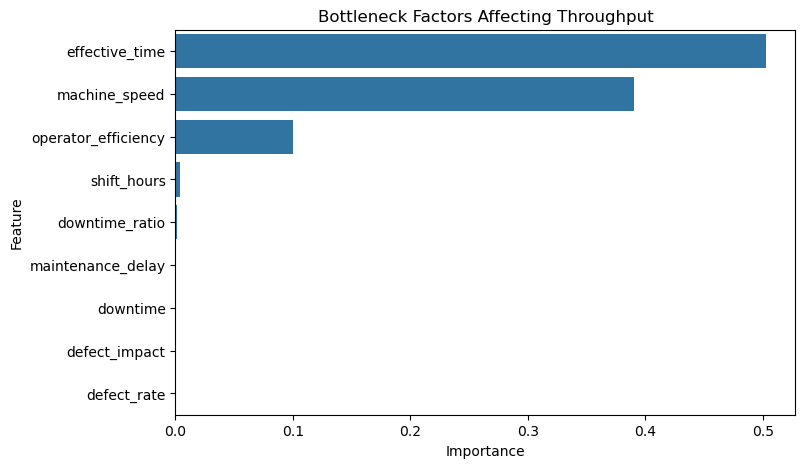

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Bottleneck Factors Affecting Throughput")
plt.show()


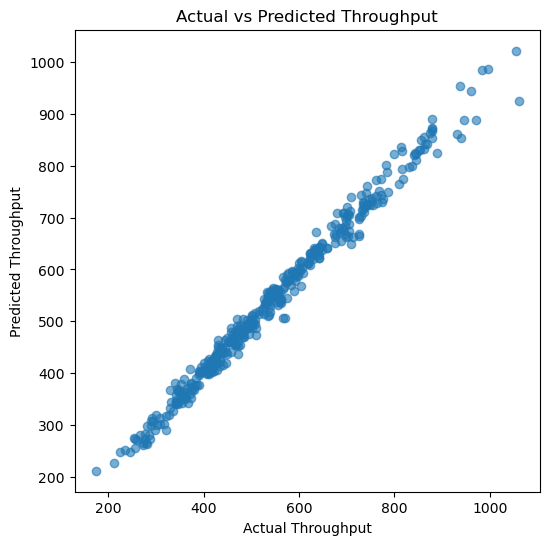

In [147]:
# Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.xlabel("Actual Throughput")
plt.ylabel("Predicted Throughput")
plt.title("Actual vs Predicted Throughput")
plt.show()


<h2 style="color:#0d6efd;"> Performance of Other Models</h2>

<b>Objective:</b>  
Compare simpler regression models to understand the impact of model complexity.


<h3 style="color:#198754;"> Decision Tree Regression</h3>

Decision Tree
MAE: 55.86839569870515
RMSE: 69.78585162936231
R²: 0.8334840311288798


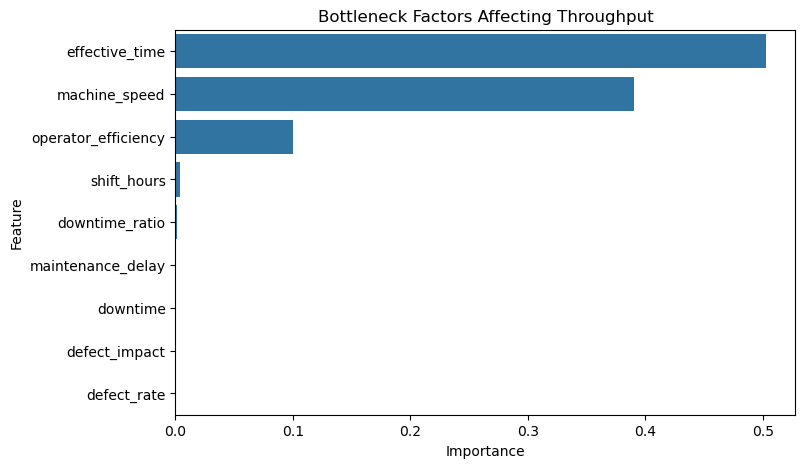

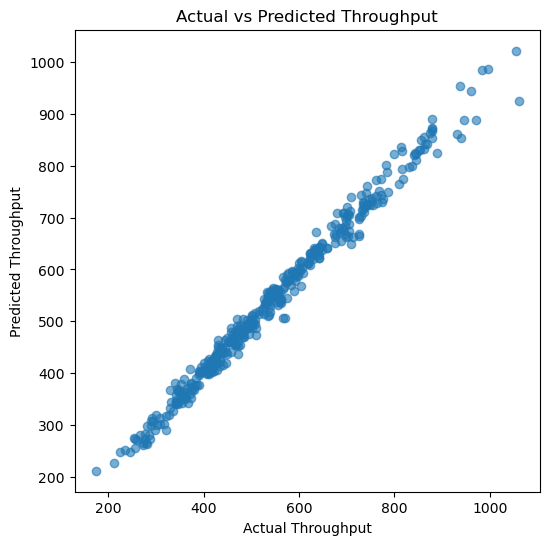

In [152]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

X = data.drop("throughput", axis=1)
y = data["throughput"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt_model = DecisionTreeRegressor(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

print("Decision Tree")
print("MAE:", mean_absolute_error(y_test, dt_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_preds)))
print("R²:", r2_score(y_test, dt_preds))

import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Bottleneck Factors Affecting Throughput")
plt.show()
# Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.xlabel("Actual Throughput")
plt.ylabel("Predicted Throughput")
plt.title("Actual vs Predicted Throughput")
plt.show()


<h3 style="color:#6f42c1;"> Linear Regression</h3>

Linear Regression
MAE: 20.19222593442968
RMSE: 27.5849464589588
R²: 0.9739825089507381


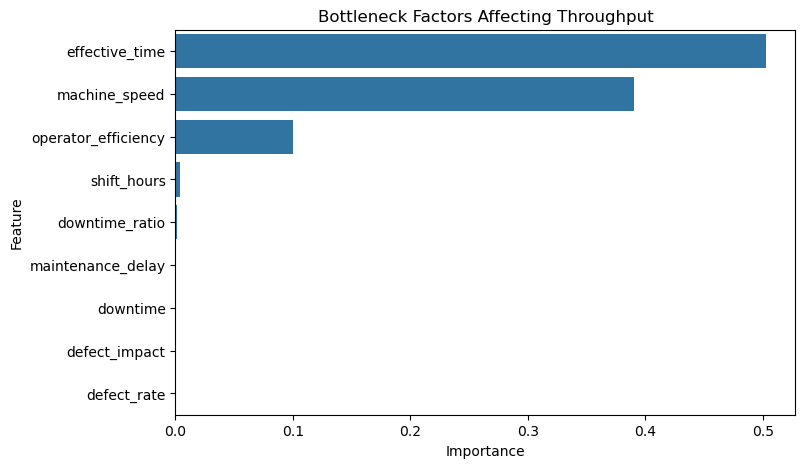

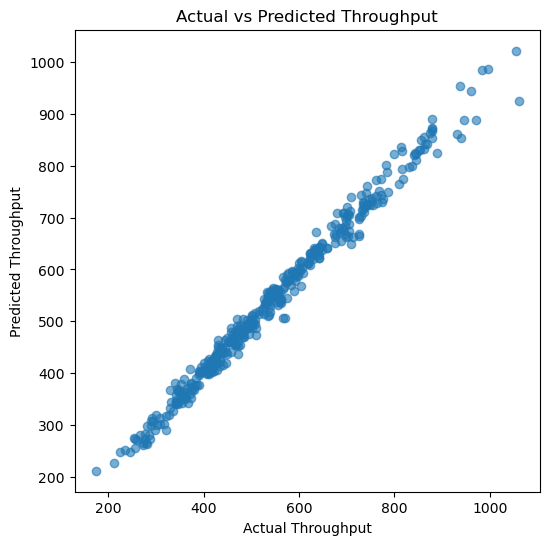

In [156]:
from sklearn.linear_model import LinearRegression

X = data.drop("throughput", axis=1)
y = data["throughput"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R²:", r2_score(y_test, lr_preds))

import matplotlib.pyplot as plt
import seaborn as sns

# Feature Importance
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Bottleneck Factors Affecting Throughput")
plt.show()
# Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.xlabel("Actual Throughput")
plt.ylabel("Predicted Throughput")
plt.title("Actual vs Predicted Throughput")
plt.show()
